<a href="https://colab.research.google.com/github/sriranjani-vs/Unsupervised-Learning-Practice/blob/main/Elbowmethod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("/content/store_customers.csv")
print("First Five Rows of Data")
print(df.head())
print("\nDataset Shape:")
print(df.shape)
print("\nDataset Description:")
print(df.describe())
print(df.info())
print(df.isnull().sum())

X = df[
    ['Annual Income (k$)',
     'Spending Score (1-100)']
]

First Five Rows of Data
   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0        1000      M  39.0                59.9                    58.0
1        1001      M  34.0                48.4                    37.0
2        1002      F  40.0                70.5                    26.0
3        1003      F  47.0                81.1                    30.0
4        1004      F  33.0                42.1                    58.0

Dataset Shape:
(1000, 5)

Dataset Description:
        CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  1000.000000  994.000000          996.000000              994.000000
mean   1499.500000   38.935614           57.149096               42.645875
std     288.819436   13.399880           28.628506               20.101589
min    1000.000000   18.000000           15.000000                1.000000
25%    1249.750000   30.000000           34.975000               31.000000
50%    1499.500000   36.000000           49.000000  

In [ ]:

import pandas as pd
df = pd.read_csv("/content/store_customers.csv")
print(pd.DataFrame(df))

     CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0          1000      M  39.0                59.9                    58.0
1          1001      M  34.0                48.4                    37.0
2          1002      F  40.0                70.5                    26.0
3          1003      F  47.0                81.1                    30.0
4          1004      F  33.0                42.1                    58.0
..          ...    ...   ...                 ...                     ...
995        1995      M  80.0               133.3                     1.0
996        1996      M  44.0                82.6                    40.0
997        1997      F  46.0                67.7                    26.0
998        1998      F  28.0                45.7                    59.0
999        1999      M  67.0               107.8                     1.0

[1000 rows x 5 columns]


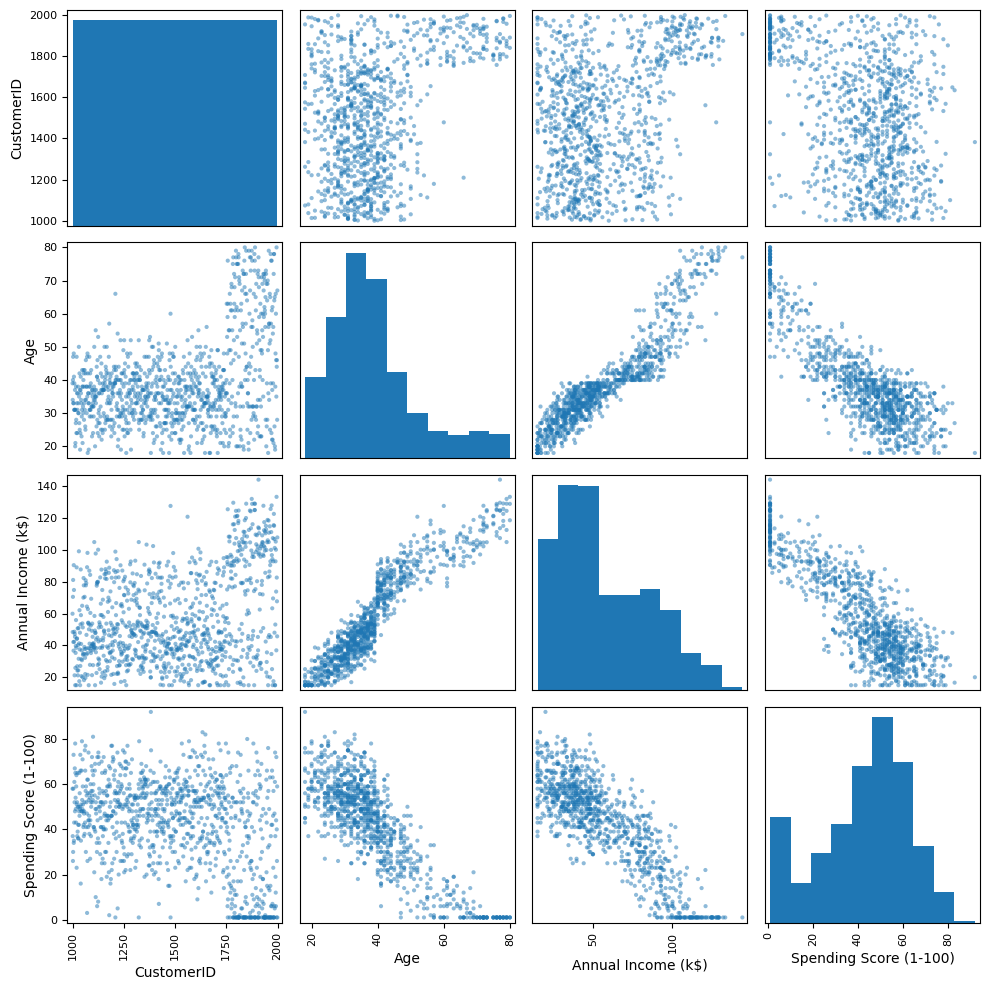

In [ ]:
import matplotlib.pyplot as plt
numeric_data = df.select_dtypes(include='number')
pd.plotting.scatter_matrix(numeric_data, figsize=(10, 10))
plt.tight_layout()
plt.show()

In [ ]:
X = df.iloc[:, [3, 4]]
X.columns = ["Annual Income","Spending Score"]
print(X)

     Annual Income  Spending Score
0             59.9            58.0
1             48.4            37.0
2             70.5            26.0
3             81.1            30.0
4             42.1            58.0
..             ...             ...
995          133.3             1.0
996           82.6            40.0
997           67.7            26.0
998           45.7            59.0
999          107.8             1.0

[1000 rows x 2 columns]


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=['Annualscaledincome','scalespending'])
display(X_scaled_df.head())

,Annualscaledincome,scalespending
0,0.096138,0.764211
1,-0.305761,-0.281009
2,0.466584,-0.828504
3,0.837031,-0.629415
4,-0.525932,0.764211


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

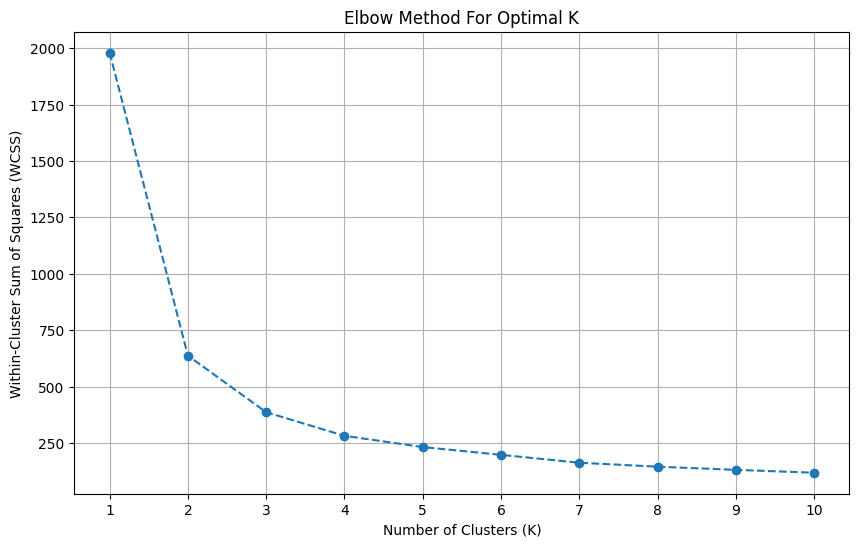

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd # Import pandas

# Load df and define X within this cell to ensure it's available
df = pd.read_csv("/content/store_customers.csv")
X = df.iloc[:, [3, 4]].copy() # Use .copy() to avoid SettingWithCopyWarning
X.columns = ["Annual Income","Spending Score"]

# Handle missing values in X by dropping rows with NaNs
X.dropna(inplace=True)

# Scale X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
# Try K from 1 to 10
for i in range(1, 11):
    # Renamed the instance variable to avoid shadowing the KMeans class
    kmeans_model = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans_model.fit(X_scaled)
    wcss.append(kmeans_model.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

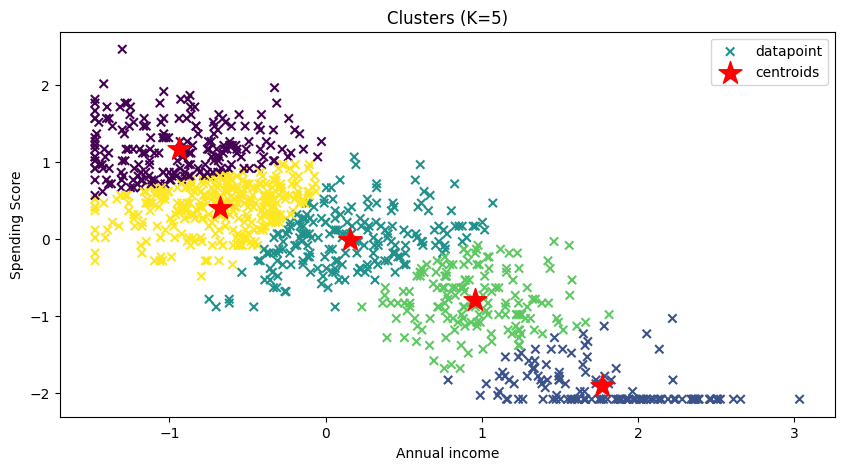

In [12]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans # Import KMeans

# Assuming an optimal K of 5 from the Elbow Method (adjust as needed)
# X_scaled is available from previous cells
final_kmeans_model = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
final_kmeans_model.fit(X_scaled)

plt.figure(figsize=(10, 5))
plt.scatter(X_scaled[:,0], X_scaled[:,1],c=final_kmeans_model.labels_,marker="x",label="datapoint")
plt.xlabel("Annual income")
plt.ylabel("Spending Score")
plt.title("Clusters (K=5)")
plt.scatter(final_kmeans_model.cluster_centers_[:,0],final_kmeans_model.cluster_centers_[:,1],marker="*",s=300,c="red",label="centroids")
plt.legend()
plt.show()